# Tutorial 8 – Equity Screening & Stock Selection Case
## FINM3422 – Professional Equity Research Workflow

**Estimated time:** ~2 hours (group-based)

---

### Scenario

You are part of a junior **equity research team** at an asset management firm.

Management has asked your team to:

> **Screen a universe of NASDAQ-listed technology companies and recommend ONE stock**
> for deeper fundamental analysis later in the course.

This notebook is intentionally structured like a **professional research notebook**,
following the modelling discipline discussed in **Lecture 6**.

You will work **collaboratively** using GitHub feature branches and pull requests.

## 1. Environment & Imports (≈5 minutes)

Professional modelling always begins by making the computing environment explicit.

Why this matters:
- Reproducibility across machines
- Clear collaboration in teams
- Fewer hidden bugs caused by implicit state

In this tutorial, we use **yfinance**, a free and stable Python library that provides
programmatic access to Yahoo Finance data.

No API key is required, which removes setup friction during tutorials.

In [4]:
# If needed (run once): pip install yfinance in console or use %pip install yfinance in your notebook

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

## What is the yfinance API?

`yfinance` is a Python wrapper around Yahoo Finance endpoints.
It allows analysts to retrieve:

- historical price data (daily, weekly, monthly)
- company metadata
- financial statements (income statement, balance sheet, cash flow)

It is:
- ✅ free
- ✅ fast to learn
- ✅ widely used for research prototyping and teaching

⚠️ Important:
`yfinance` is **not an institutional-grade data source** (e.g. Bloomberg or Refinitiv),
but it is perfectly suitable for **learning professional modelling workflows**.

## 2. Define the Investment Universe (≈5 minutes)

Equity research always begins with a clearly defined **investment universe**.

We restrict attention to a curated list of **large‑cap NASDAQ technology companies**.

Using a fixed universe ensures:
- Comparability across tutorial teams
- Stable API behaviour in class
- Focus on modelling rather than data hunting

In [5]:
tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "ADBE",  # Adobe
    "META",  # Meta Platforms
    "CRM",   # Salesforce
    "ORCL",  # Oracle
    "NOW",   # ServiceNow
    "INTU",  # Intuit
    "AMD"    # Advanced Micro Devices
]

## 3. Price Data Ingestion – API → DataFrame (≈15 minutes)

In professional workflows, analysts **do not manually download CSV files**.
Instead, data is pulled programmatically via APIs.

The main function used by yfinance is:

    yf.download()

### Key parameters you must understand

- `tickers`
  A single ticker (string) or multiple tickers (list)

- `interval`
  Controls **frequency** of observations  
  Examples:
  - `"1d"`  → daily data
  - `"1wk"` → weekly data
  - `"1mo"` → monthly data

- `period`
  Controls **how much history** is returned  
  Examples:
  - `"1y"`   → last year
  - `"5y"`   → last 5 years
  - `"max"`  → full available history

⚠️ **Critical rule**
> Never rely on API defaults. Always specify `period` explicitly.

## Why We Use Monthly Data in This Tutorial

In FINM3422:
- portfolio returns are monthly
- performance metrics are monthly
- Assignment 2 uses monthly frequency

Therefore, we deliberately request:
- `interval = "1mo"` → monthly observations
- `period = "max"`   → long historical window

This ensures:
- frequency is correct before computing returns
- enough observations exist for rolling metrics
- alignment with Lecture 6 modelling discipline

In [ ]:
# TODO:
# Use yf.download to retrieve monthly adjusted prices
# - interval="1mo"
# - period="max"
# - auto_adjust=True
# Then:
# - keep adjusted close prices
# - ensure DatetimeIndex
# - sort index

prices = yf.download(
tickers,
period="max",
interval="1mo",
auto_adjust=True,
progress=False
)["Close"]

prices = prices.dropna(how="all").sort_index() # Only removes a row if all values are zero across the column.
display(prices)


Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
1985-01-01,0.099152,NaN,17.562500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-02-01,0.084621,NaN,16.625000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-03-01,0.075646,NaN,16.687500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-04-01,0.072655,NaN,13.937500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-05-01,0.059406,NaN,13.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-01-01,259.237427,293.250000,236.729996,211.760376,496.468567,715.887085,429.310120,117.010002,191.119659,163.574799
2026-02-01,263.933014,262.410004,200.210007,194.304047,407.769867,647.625488,391.845612,108.010002,177.180420,144.893936
2026-03-01,253.789993,243.080002,203.429993,186.204300,431.047943,571.640564,370.170013,104.550003,174.390549,146.597992


## 4. Data Inspection & Sanity Checks (≈10 minutes)

Before computing metrics, analysts **inspect the raw data**.

You should check:
- `.info()`
- missing values (`.isna().sum()`)
- index type (`type(df.index)`)
- chronological ordering

### Important modelling principle (Lecture 6)

> NA does **not** mean bad data.
> It often means the company did not exist yet (IPO timing).

Different firms have different listing dates.
This is **economically correct**, not an error.

In [17]:
# TODO:
# Inspect the price DataFrame:
# - info()
# - missing values
# - index properties

prices.info()

prices.isna().sum()

print(type(prices.index))


<class 'pandas.DataFrame'>
DatetimeIndex: 497 entries, 1985-01-01 to 2026-05-01
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    497 non-null    float64
 1   ADBE    478 non-null    float64
 2   AMD     497 non-null    float64
 3   CRM     264 non-null    float64
 4   INTU    399 non-null    float64
 5   META    169 non-null    float64
 6   MSFT    483 non-null    float64
 7   NOW     168 non-null    float64
 8   NVDA    329 non-null    float64
 9   ORCL    483 non-null    float64
dtypes: float64(10)
memory usage: 42.7 KB
<class 'pandas.DatetimeIndex'>


## 5. Returns & Performance Metrics (≈15 minutes)

Equity screeners often include **recent market performance**
(e.g. momentum or confirmation).

Tasks:
- Compute monthly returns
- Compute trailing 12‑month total return

⚠️ Always fix frequency *before* computing returns.

In [19]:
# TODO:
# 1. Compute monthly returns using pct_change()
# 2. Compute trailing 12‑month total return

returns = prices.pct_change().dropna()

ret_12m = (1 + returns).rolling(12).apply(
    np.prod, raw=True
) - 1

latest_12m = ret_12m.iloc[-1]


## 6. Visual Diagnostics – Wealth Index (≈15 minutes)

Before trusting any metric, professional analysts **plot a wealth index**.

A wealth index answers:
> What happens to $1 invested over time?

This diagnostic reveals:
- missing months
- compounding errors
- extreme outliers dominating results

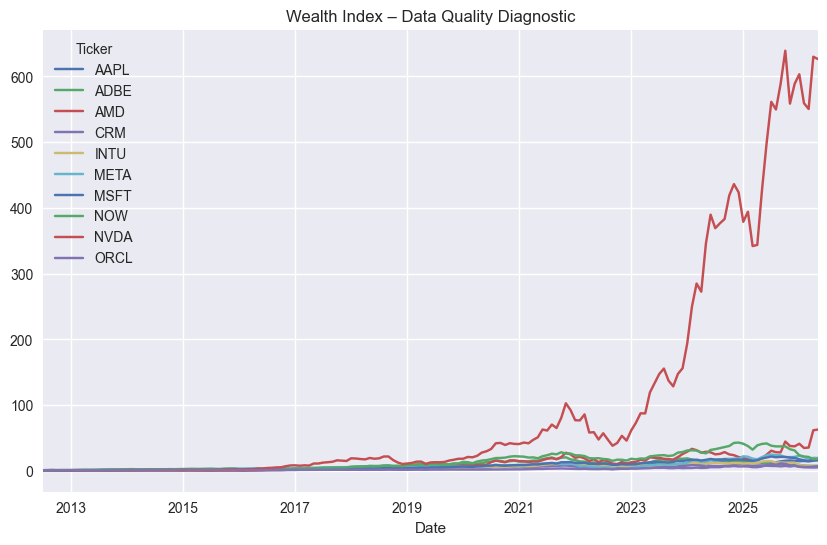

In [22]:
# TODO:
# Construct and plot wealth indices
# Plot at least 3 stocks
# Add a brief interpretation

(1 + returns).cumprod().plot(
    figsize=(10, 6),
    title="Wealth Index – Data Quality Diagnostic"
)
plt.show()

## 7. Fundamental Indicators – Growth & Quality (≈20 minutes)

Market prices alone are not sufficient for equity analysis.

We complement price performance with **fundamentals**.

Two indicators:
- **Revenue growth** (latest year vs previous year)
- **Operating margin** (operating income / revenue)

Financial statements are accessed using:

    yf.Ticker("AAPL").financials

In [23]:
# TODO:
# For each ticker:
# - retrieve financial statements using yf.Ticker
# - compute revenue growth
# - compute operating margin
# Store results in a DataFrame

fundamentals = []

for t in tickers:
    fin = yf.Ticker(t).financials

    rev_growth = (
        fin.loc["Total Revenue"].iloc[0] /
        fin.loc["Total Revenue"].iloc[1] - 1
    )

    op_margin = (
        fin.loc["Operating Income"].iloc[0] /
        fin.loc["Total Revenue"].iloc[0]
    )

    fundamentals.append({
        "Ticker": t,
        "RevenueGrowth": rev_growth,
        "OperatingMargin": op_margin
    })

fund_df = pd.DataFrame(fundamentals).set_index("Ticker")

## 8. Screening Table Construction (≈15 minutes)

Professional screeners combine **all signals into one master table**.

Structure:
- each row → one stock
- each column → one screening signal

This table forms the basis for ranking and decision‑making.

In [24]:
# TODO:
# Combine:
# - 12‑month return
# - revenue growth
# - operating margin
# into a single screening table

screen = fund_df.join(latest_12m.rename("Return12M"))
screen

,RevenueGrowth,OperatingMargin,Return12M
Ticker,,,
AAPL,0.064255,0.319708,0.400851
MSFT,0.149322,0.456220,-0.092856
NVDA,0.654735,0.603817,0.468932
ADBE,0.105278,0.366275,-0.396010
META,0.221670,0.414379,-0.056898
CRM,0.095791,0.214738,-0.302137
ORCL,0.083798,0.314500,0.048474
NOW,0.208849,0.137370,-0.549199
INTU,0.156340,0.262227,-0.466088


## 9. Ranking & Shortlisting Logic (≈15 minutes)

Equity screening is about **narrowing the universe**, not precision.

Rank stocks using:
- revenue growth
- operating margin
- 12‑month performance

Combine ranks into a **composite score**.

There is no single correct answer —
only defensible logic that can be explained.

In [25]:
# TODO:
# Rank each metric
# Compute composite score
# Sort stocks from most to least attractive

screen["Score"] = screen.rank().mean(axis=1)

screen_sorted = screen.sort_values("Score", ascending=False)
screen_sorted

,RevenueGrowth,OperatingMargin,Return12M,Score
Ticker,,,,
NVDA,0.654735,0.603817,0.468932,9.666667
META,0.221670,0.414379,-0.056898,7.333333
AMD,0.343378,0.106643,2.256028,6.666667
MSFT,0.149322,0.456220,-0.092856,6.333333
AAPL,0.064255,0.319708,0.400851,5.000000
ADBE,0.105278,0.366275,-0.396010,4.666667
ORCL,0.083798,0.314500,0.048474,4.666667
INTU,0.156340,0.262227,-0.466088,4.000000
CRM,0.095791,0.214738,-0.302137,3.333333


## 10. Stock Selection – Analyst Decision (≈10 minutes)

Your team must now make a **judgement call**.

Select **ONE stock** to recommend for deeper analysis.

Write as if presenting to an **investment committee**.

In [ ]:
### Selected Stock

### Analyst Rationale
# - Growth outlook:
# - Profitability / quality:
# - Market performance:
# - Key risks:

SyntaxError: invalid syntax (255545209.py, line 4)

## 11. GitHub Collaboration Reflection (≈10 minutes)

Equity research is a **team activity**.

Document:
- Who worked on which sections
- How feature branches and pull requests were used
- Any challenges encountered

- Member A:
- Member B:
- Member C: